# we will study here

In [1]:
from eeg_bci.data.paths import resolve_data_dir

data_dir = resolve_data_dir("/workspaces/BRAINDECODE/data/moabb")
data_dir

PosixPath('/workspaces/BRAINDECODE/data/moabb')

In [2]:
from braindecode.datasets import MOABBDataset
import moabb

moabb.set_download_dir(str(data_dir))


subject_id = 1

dataset = MOABBDataset(dataset_name="Liu2024", subject_ids=[subject_id])

Attempting to create new mne-python configuration file:
/home/vscode/.mne/mne-python.json
Could not read the /home/vscode/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)


/workspaces/BRAINDECODE/.venv/lib/python3.11/site-packages/moabb/datasets/download.py:97: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_LIU2024_PATH"
  set_config(key, get_config("MNE_DATA"))


Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]


/workspaces/BRAINDECODE/.venv/lib/python3.11/site-packages/moabb/datasets/liu2024.py:521: RuntimeWarning: The unit for channel(s) STI has changed from NA to V.
  raw.set_channel_types(mapping)


## Understand the Liu2024 data structure

Keep this mental model while reading the cells below:

`dataset` -> one or more `RawDataset` recordings -> one MNE `Raw` object per recording -> a continuous signal matrix plus event annotations.

For subject 1 here, we loaded one continuous recording. The class labels are not a separate `y` array yet. This is not about separating by subject id; it means the `left_hand` / `right_hand` labels are stored as timed annotations inside the recording. They become normal supervised labels only after the later windowing step.

In [3]:
dataset.description

,subject,session,run
0,1,0,0


### Recording metadata vs class labels

`dataset.description` is one row per recording. It tells us which subject/session/run the recording came from. It does not contain the motor-imagery class labels.

For Liu2024, `session = 0` is just a session identifier. It is not the official `0train` / `1test` split that BCI Competition IV 2a has. The class labels live lower down, inside `raw.annotations`.

In [4]:
import pandas as pd

recording = dataset.datasets[0]
raw = recording.raw

overview = pd.Series(
    {
        "Braindecode container": type(dataset).__name__,
        "number of recordings": len(dataset.datasets),
        "recording object": type(recording).__name__,
        "MNE object": type(raw).__name__,
        "sampling frequency (Hz)": raw.info["sfreq"],
        "duration (s)": raw.n_times / raw.info["sfreq"],
        "channels": raw.info["nchan"],
        "time samples": raw.n_times,
        "annotations/events": len(raw.annotations),
    },
    name="value",
).to_frame()

overview

,value
Braindecode container,MOABBDataset
number of recordings,1
recording object,RawDataset
MNE object,RawEDF
sampling frequency (Hz),500.0
duration (s),320.0
channels,32
time samples,160000
annotations/events,40


### The raw signal matrix

`raw` is still continuous EEG. Numerically, `raw.get_data()` is arranged as `(channels, time_samples)`. At 500 Hz, 500 time samples represent one second.

In [5]:
raw_matrix = raw.get_data()

print(f"raw_matrix.shape = {raw_matrix.shape}  # (channels, time_samples)")
print(f"{raw.info['sfreq']:.0f} samples = 1 second")
print(f"{raw.n_times} samples / {raw.info['sfreq']:.0f} Hz = {raw.n_times / raw.info['sfreq']:.1f} seconds")

raw_matrix.shape = (32, 160000)  # (channels, time_samples)
500 samples = 1 second
160000 samples / 500 Hz = 320.0 seconds


### Channels

Rows of the raw matrix are channels. Liu2024 includes EEG channels, EOG channels, and one stimulus channel. Later preprocessing/windowing usually selects only EEG channels for the neural network.

In [6]:
channel_table = pd.DataFrame(
    {
        "index": range(len(raw.ch_names)),
        "name": raw.ch_names,
        "type": raw.get_channel_types(),
    }
)

display(channel_table["type"].value_counts().rename("n_channels").to_frame())
channel_table

,n_channels
type,
eeg,29
eog,2
stim,1


,index,name,type
0,0,FP1,eeg
1,1,FP2,eeg
2,2,Fz,eeg
3,3,F3,eeg
4,4,F4,eeg
5,5,F7,eeg
6,6,F8,eeg
7,7,FCz,eeg
8,8,FC3,eeg
9,9,FC4,eeg


### Labels before windowing

The motor-imagery labels live in `raw.annotations`. Each annotation says: at this time in the continuous recording, a labeled event happened. For this loaded subject, the class names are `left_hand` and `right_hand`.

In [7]:
annotations = pd.DataFrame(
    {
        "onset_sec": raw.annotations.onset,
        "duration_sec": raw.annotations.duration,
        "description": raw.annotations.description,
    }
)

display(annotations["description"].value_counts().rename("n_events").to_frame())
annotations.head(10)

,n_events
description,
left_hand,20
right_hand,20


,onset_sec,duration_sec,description
0,2.006,4.0,left_hand
1,10.004,4.0,right_hand
2,18.004,4.0,left_hand
3,26.006,4.0,right_hand
4,34.006,4.0,left_hand
5,42.006,4.0,right_hand
6,50.006,4.0,left_hand
7,58.006,4.0,right_hand
8,66.006,4.0,left_hand
9,74.006,4.0,right_hand


### Event timing and class balance

Now we convert the annotations into a clearer event table. Each row is one future training example before it has been cut out of the raw signal.

In [8]:
sfreq = raw.info["sfreq"]

event_table = annotations.copy()
event_table.insert(0, "event_index", range(len(event_table)))
event_table["onset_sample"] = (event_table["onset_sec"] * sfreq).round().astype(int)
event_table["stop_sec"] = event_table["onset_sec"] + event_table["duration_sec"]
event_table["stop_sample"] = (event_table["stop_sec"] * sfreq).round().astype(int)
event_table["gap_from_previous_sec"] = event_table["onset_sec"].diff()

event_summary = (
    event_table.groupby("description")
    .agg(
        n_events=("description", "size"),
        first_onset_sec=("onset_sec", "min"),
        last_onset_sec=("onset_sec", "max"),
        mean_duration_sec=("duration_sec", "mean"),
    )
)

display(event_summary)
event_table.head(12)

,n_events,first_onset_sec,last_onset_sec,mean_duration_sec
description,,,,
left_hand,20,2.006,306.014,4.0
right_hand,20,10.004,314.016,4.0


,event_index,onset_sec,duration_sec,description,onset_sample,stop_sec,stop_sample,gap_from_previous_sec
0,0,2.006,4.0,left_hand,1003,6.006,3003,NaN
1,1,10.004,4.0,right_hand,5002,14.004,7002,7.998
2,2,18.004,4.0,left_hand,9002,22.004,11002,8.000
3,3,26.006,4.0,right_hand,13003,30.006,15003,8.002
4,4,34.006,4.0,left_hand,17003,38.006,19003,8.000
5,5,42.006,4.0,right_hand,21003,46.006,23003,8.000
6,6,50.006,4.0,left_hand,25003,54.006,27003,8.000
7,7,58.006,4.0,right_hand,29003,62.006,31003,8.000
8,8,66.006,4.0,left_hand,33003,70.006,35003,8.000
9,9,74.006,4.0,right_hand,37003,78.006,39003,8.000


### Event timeline

This plot answers a simple question: where in the continuous recording do the `left_hand` and `right_hand` events happen?

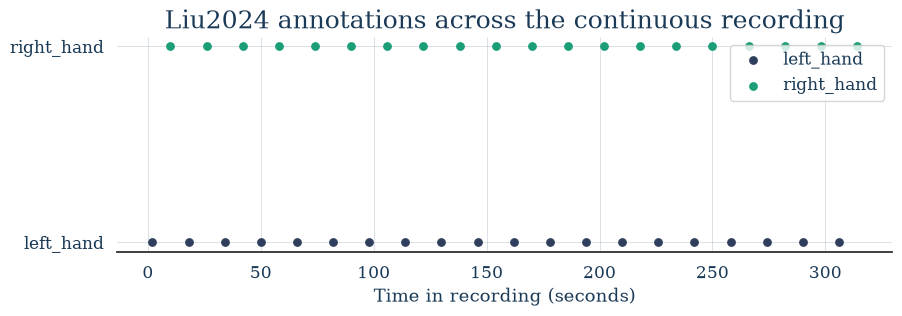

In [9]:
import matplotlib.pyplot as plt

labels = sorted(event_table["description"].unique())
label_to_y = {label: idx for idx, label in enumerate(labels)}

fig, ax = plt.subplots(figsize=(10, 2.8))
for label in labels:
    label_events = event_table[event_table["description"] == label]
    ax.scatter(
        label_events["onset_sec"],
        [label_to_y[label]] * len(label_events),
        s=28,
        label=label,
    )

ax.set_yticks(list(label_to_y.values()))
ax.set_yticklabels(labels)
ax.set_xlabel("Time in recording (seconds)")
ax.set_title("Liu2024 annotations across the continuous recording")
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="upper right")
plt.show()

### Preview one future window

Before creating a `windows_dataset`, we can manually look at the raw EEG segment after one event. This is not preprocessing or training yet; it is just a sanity check for what a future window will contain.

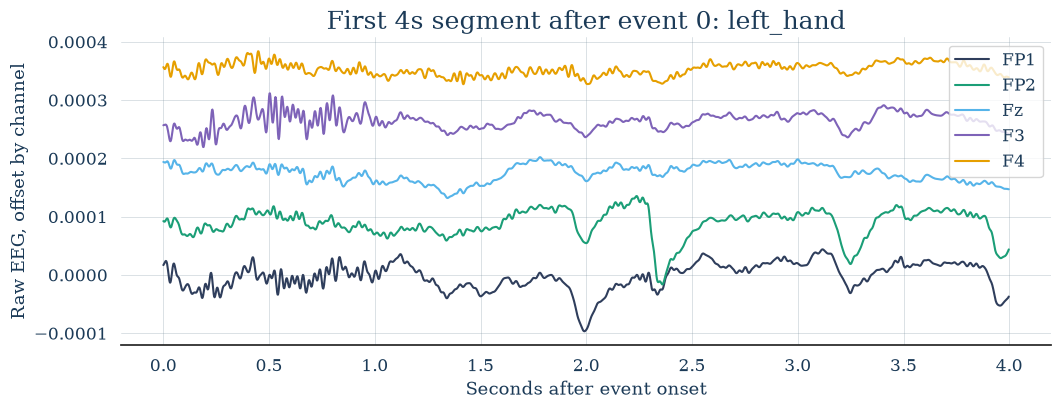

In [10]:
import numpy as np

preview_seconds = 4.0
preview_event = event_table.iloc[0]
start_sample = int(preview_event["onset_sample"])
stop_sample = min(raw.n_times, start_sample + int(preview_seconds * sfreq))

preview_eeg_channels = channel_table.loc[
    channel_table["type"] == "eeg", "name"
].head(5).tolist()
preview_raw = raw.copy().pick(preview_eeg_channels)
preview_data = preview_raw.get_data(start=start_sample, stop=stop_sample)
time_axis = np.arange(preview_data.shape[1]) / sfreq

channel_scale = np.nanmedian(np.std(preview_data, axis=1))
if not np.isfinite(channel_scale) or channel_scale == 0:
    channel_scale = 1.0
offsets = np.arange(len(preview_eeg_channels)) * channel_scale * 6

fig, ax = plt.subplots(figsize=(12, 4))
for channel_idx, channel_name in enumerate(preview_eeg_channels):
    ax.plot(
        time_axis,
        preview_data[channel_idx] + offsets[channel_idx],
        label=channel_name,
    )

ax.set_title(
    f"First {preview_seconds:.0f}s segment after event "
    f"{int(preview_event['event_index'])}: {preview_event['description']}"
)
ax.set_xlabel("Seconds after event onset")
ax.set_ylabel("Raw EEG, offset by channel")
ax.legend(loc="upper right")
plt.show()

### Windowing plan from what we learned

After this inspection, the first clean windowing plan is: keep EEG channels, map `left_hand` to `0` and `right_hand` to `1`, cut one 4-second window after each event, then create our own train/test split because Liu2024 does not provide `0train` / `1test` sessions.

In [11]:
window_plan = pd.Series(
    {
        "classes": sorted(event_table["description"].unique()),
        "mapping": {"left_hand": 0, "right_hand": 1},
        "channels for model": "EEG only",
        "window length (seconds)": 4.0,
        "window length (samples)": int(4.0 * sfreq),
        "windows per event": 1,
        "train/test split": "manual after windowing",
    },
    name="choice",
).to_frame()

window_plan

,choice
classes,"[left_hand, right_hand]"
mapping,"{'left_hand': 0, 'right_hand': 1}"
channels for model,EEG only
window length (seconds),4.0
window length (samples),2000
windows per event,1
train/test split,manual after windowing


### What changes after windowing

Right now the data are continuous. Later, `create_windows_from_events(...)` uses these annotation times to cut the recording into trial windows. After that step, each dataset item becomes one supervised example: an EEG window `X`, a label `y`, and metadata describing where that window came from.

In [12]:
from braindecode.preprocessing import create_windows_from_events

sfreq = raw.info["sfreq"]
windows_dataset = create_windows_from_events(
    dataset,
    trial_start_offset_samples=0,
    trial_stop_offset_samples=0,
    window_size_samples=int(4.0 * sfreq),
    window_stride_samples=int(4.0 * sfreq),
    mapping={"left_hand": 0, "right_hand": 1},
    picks="eeg",
    preload=True,
)

windows_dataset

/workspaces/BRAINDECODE/.venv/lib/python3.11/site-packages/braindecode/preprocessing/windowers.py:184: UserWarning: Using reject or picks or flat or dropping bad windows means mne Epochs are created, which will be substantially slower and may be deprecated in the future.
  warnings.warn(


<BaseConcatDataset | 1 WindowsDataset(s) | 40 total samples>
  Sfreq*: 500.0 Hz
  Channels*: 29 (29 EEG)
  Ch. names*: FP1, FP2, Fz, F3, F4, F7, F8, FCz, FC3, FC4, ... (+19 more)
  Montage*: head
  (* from first recording)
  Description: 1 recordings × 3 columns [subject, session, run]
  Window: 2000 samples (4.000 s)
  Targets: 2 unique ({0: 20, 1: 20})

In [13]:
print(windows_dataset.description)
print(len(windows_dataset))

metadata = windows_dataset.get_metadata()
print(metadata.head())
print(metadata.shape)
print(metadata["target"].value_counts())

   subject session run
0        1       0   0
40
   i_window_in_trial  i_start_in_trial  i_stop_in_trial  target  subject  \
0                  0              1003             3003       0        1   
1                  0              5002             7002       1        1   
2                  0              9002            11002       0        1   
3                  0             13003            15003       1        1   
4                  0             17003            19003       0        1   

  session run  
0       0   0  
1       0   0  
2       0   0  
3       0   0  
4       0   0  
(40, 7)
target
0    20
1    20
Name: count, dtype: int64


In [26]:
import numpy as np
from torch.utils.data import Subset

# Get metadata after create_windows_from_events
metadata = windows_dataset.get_metadata()

# Order windows by their position in the continuous recording
sorted_idx = metadata["i_start_in_trial"].to_numpy().argsort()

# Chronological 80/20 split
n_total = len(sorted_idx)
n_train = int(0.8 * n_total)

train_idx = sorted_idx[:n_train].tolist()
test_idx = sorted_idx[n_train:].tolist()

train_set = Subset(windows_dataset, train_idx)
test_set = Subset(windows_dataset, test_idx)

print(f"train: {len(train_set)}, test: {len(test_set)}")

train: 32, test: 8


In [27]:
print("train start samples:", metadata.iloc[train_idx]["i_start_in_trial"].values)
print("test  start samples:", metadata.iloc[test_idx]["i_start_in_trial"].values)

train start samples: [  1003   5002   9002  13003  17003  21003  25003  29003  33003  37003
  41004  45003  49003  53002  57002  61004  65003  69009  73009  77009
  81010  85011  89009  93019  97010 101010 105010 109007 113007 117007
 121006 125007]
test  start samples: [129006 133006 137006 141007 145007 149007 153007 157008]


In [28]:
from collections import defaultdict

metadata = windows_dataset.get_metadata()
targets = metadata["target"].to_numpy()

train_indices, test_indices = [], []

for label in np.unique(targets):
    class_idx = np.where(targets == label)[0]
    # Sort this class by time
    class_idx_sorted = class_idx[np.argsort(metadata["i_start_in_trial"].iloc[class_idx].values)]
    
    n_train = int(0.8 * len(class_idx_sorted))
    train_indices.extend(class_idx_sorted[:n_train])
    test_indices.extend(class_idx_sorted[n_train:])

train_set = Subset(windows_dataset, train_indices)
test_set = Subset(windows_dataset, test_indices)

print(f"train: {len(train_set)}, test: {len(test_set)}")
print("train labels:", np.bincount(targets[train_indices]))
print("test labels:", np.bincount(targets[test_indices]))

train: 32, test: 8
train labels: [16 16]
test labels: [4 4]


In [29]:
from sklearn.model_selection import TimeSeriesSplit

metadata = windows_dataset.get_metadata()
sorted_idx = metadata["i_start_in_trial"].to_numpy().argsort()

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(tscv.split(sorted_idx)):
    train_subset = Subset(windows_dataset, sorted_idx[train_idx].tolist())
    test_subset = Subset(windows_dataset, sorted_idx[test_idx].tolist())
    print(f"Fold {fold}: train={len(train_subset)}, test={len(test_subset)}")

Fold 0: train=10, test=6
Fold 1: train=16, test=6
Fold 2: train=22, test=6
Fold 3: train=28, test=6
Fold 4: train=34, test=6


In [31]:
import numpy as np
from torch.utils.data import Subset

metadata = windows_dataset.get_metadata()
targets = metadata["target"].to_numpy()

# ============================================================
# Step 1: chronological stratified train / test split
# ============================================================
train_indices, test_indices = [], []

for label in np.unique(targets):
    class_idx = np.where(targets == label)[0]
    class_idx_sorted = class_idx[
        np.argsort(metadata["i_start_in_trial"].iloc[class_idx].values)
    ]
    n_train = int(0.8 * len(class_idx_sorted))
    train_indices.extend(class_idx_sorted[:n_train])
    test_indices.extend(class_idx_sorted[n_train:])

# ============================================================
# Step 2: chronological train / validation split from train pool
# ============================================================
train_targets = targets[train_indices]
train_metadata = metadata.iloc[train_indices]

train_final_indices, val_indices = [], []

for label in np.unique(train_targets):
    class_idx = np.where(train_targets == label)[0]
    class_idx_sorted = class_idx[
        np.argsort(train_metadata["i_start_in_trial"].iloc[class_idx].values)
    ]
    n_train_final = int(0.8 * len(class_idx_sorted))
    # Map back to indices in the original windows_dataset
    train_final_indices.extend(np.array(train_indices)[class_idx_sorted[:n_train_final]])
    val_indices.extend(np.array(train_indices)[class_idx_sorted[n_train_final:]])

# ============================================================
# Build datasets
# ============================================================
train_set = Subset(windows_dataset, train_final_indices)
val_set = Subset(windows_dataset, val_indices)
test_set = Subset(windows_dataset, test_indices)

print(f"train: {len(train_set)}, val: {len(val_set)}, test: {len(test_set)}")
print("train labels:", np.bincount(targets[train_final_indices]))
print("val labels:  ", np.bincount(targets[val_indices]))
print("test labels: ", np.bincount(targets[test_indices]))

train: 24, val: 8, test: 8
train labels: [12 12]
val labels:   [4 4]
test labels:  [4 4]


# don't look this now

In [3]:
import numpy as np

from braindecode.preprocessing import (
    Preprocessor,
    exponential_moving_standardize,
    preprocess,
)

# Motor imagery band
low_cut_hz = 8.0
high_cut_hz = 30.0

# Exponential moving standardization
factor_new = 1e-3
init_block_size = 1000

preprocessors = [
    # Keep only EEG channels
    Preprocessor("pick_types", eeg=True, meg=False, stim=False, eog=False),

    # Convert from V to µV
    Preprocessor(
        lambda data, factor: np.multiply(data, factor),
        factor=1e6,
    ),

    # Band-pass filter for MI rhythms
    Preprocessor(
        "filter",
        l_freq=low_cut_hz,
        h_freq=high_cut_hz,
    ),

    # Standardize each continuous recording
    Preprocessor(
        exponential_moving_standardize,
        factor_new=factor_new,
        init_block_size=init_block_size,
    ),
]

preprocess(dataset, preprocessors, n_jobs=-1)

/workspaces/BRAINDECODE/.venv/lib/python3.11/site-packages/braindecode/preprocessing/preprocess.py:78: UserWarning: apply_on_array can only be True if fn is a callable function. Automatically correcting to apply_on_array=False.
  warn(
/workspaces/BRAINDECODE/.venv/lib/python3.11/site-packages/braindecode/preprocessing/preprocess.py:76: UserWarning: Preprocessing choices with lambda functions cannot be saved.
  warn("Preprocessing choices with lambda functions cannot be saved.")


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 825 samples (1.650 s)



<BaseConcatDataset | 1 RawDataset(s) | 160000 total samples>
  Sfreq*: 500.0 Hz
  Channels*: 29 (29 EEG)
  Ch. names*: FP1, FP2, Fz, F3, F4, F7, F8, FCz, FC3, FC4, ... (+19 more)
  Montage*: head
  Duration*: 320.0 s
  (* from first recording)
  Description: 1 recordings × 3 columns [subject, session, run]

In [5]:
from braindecode.preprocessing import create_windows_from_events

# Liu2024 sampling rate should be 500 Hz
sfreq = dataset.datasets[0].raw.info["sfreq"]
assert all(ds.raw.info["sfreq"] == sfreq for ds in dataset.datasets)

mi_window_seconds = 4.0
window_size_samples = int(mi_window_seconds * sfreq)

windows_dataset = create_windows_from_events(
    dataset,
    trial_start_offset_samples=0,
    trial_stop_offset_samples=0,
    window_size_samples=window_size_samples,
    window_stride_samples=window_size_samples,
    mapping={
        "left_hand": 0,
        "right_hand": 1,
    },
    picks="eeg",
    preload=True,
)

/workspaces/BRAINDECODE/.venv/lib/python3.11/site-packages/braindecode/preprocessing/windowers.py:184: UserWarning: Using reject or picks or flat or dropping bad windows means mne Epochs are created, which will be substantially slower and may be deprecated in the future.
  warnings.warn(


In [6]:
print(windows_dataset.description)
print(len(windows_dataset))

metadata = windows_dataset.get_metadata()
print(metadata.head())
print(metadata.shape)
print(metadata["target"].value_counts())

   subject session run
0        3       0   0
40
   i_window_in_trial  i_start_in_trial  i_stop_in_trial  target  subject  \
0                  0              1008             3008       0        3   
1                  0              5003             7003       1        3   
2                  0              9003            11003       0        3   
3                  0             13003            15003       1        3   
4                  0             17003            19003       0        3   

  session run  
0       0   0  
1       0   0  
2       0   0  
3       0   0  
4       0   0  
(40, 7)
target
0    20
1    20
Name: count, dtype: int64


In [6]:
splitted = windows_dataset.split("session")
train_set = splitted["0train"]  # Session train
test_set = splitted["1test"]  # Session evaluation

In [7]:
import torch

from braindecode.models import ShallowFBCSPNet
from braindecode.util import set_random_seeds

cuda = torch.cuda.is_available()  # check if GPU is available, if True chooses to use it
device = "cuda" if cuda else "cpu"
if cuda:
    torch.backends.cudnn.benchmark = True
seed = 20200220
set_random_seeds(seed=seed, cuda=cuda)

n_classes = 4
classes = list(range(n_classes))
# Extract number of chans and time steps from dataset
n_channels = windows_dataset[0][0].shape[0]
n_times = windows_dataset[0][0].shape[1]

model = ShallowFBCSPNet(
    n_chans=n_channels,
    n_outputs=n_classes,
    n_times=n_times,
    final_conv_length="auto",
)

# Display torchinfo table describing the model
print(model)

# Send model to GPU
if cuda:
    model.cuda()

Layer (type (var_name):depth-idx)             Input Shape               Output Shape              Param #                   Kernel Shape
ShallowFBCSPNet (ShallowFBCSPNet)             [1, 22, 1125]             [1, 4]                    --                        --
├─Ensure4d (ensuredims): 1-1                  [1, 22, 1125]             [1, 22, 1125, 1]          --                        --
├─Rearrange (dimshuffle): 1-2                 [1, 22, 1125, 1]          [1, 1, 1125, 22]          --                        --
├─CombinedConv (conv_time_spat): 1-3          [1, 1, 1125, 22]          [1, 40, 1101, 1]          36,240                    --
├─BatchNorm2d (bnorm): 1-4                    [1, 40, 1101, 1]          [1, 40, 1101, 1]          80                        --
├─Square (conv_nonlin_exp): 1-5               [1, 40, 1101, 1]          [1, 40, 1101, 1]          --                        --
├─AvgPool2d (pool): 1-6                       [1, 40, 1101, 1]          [1, 40, 69, 1]            -- 

In [8]:
from skorch.callbacks import LRScheduler

from braindecode import EEGClassifier

lr = 0.0625 * 0.01
weight_decay = 0
batch_size = 64
n_epochs = 2

clf = EEGClassifier(
    model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    train_split=None,
    optimizer__lr=lr,
    optimizer__weight_decay=weight_decay,
    batch_size=batch_size,
    callbacks=[
        "accuracy",
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
    ],
    device=device,
    classes=classes,
    max_epochs=n_epochs,
)
# Model training for a specified number of epochs. `y` is None as it is already supplied
# in the dataset.
clf.fit(train_set, y=None)

# evaluated the model after training
y_test = test_set.get_metadata().target
test_acc = clf.score(test_set, y=y_test)
print(f"Test acc: {(test_acc * 100):.2f}%")

  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.2500        1.6341  0.0006  0.9713
      2            0.2500        1.3826  0.0000  0.8117
Test acc: 25.00%


<Axes: title={'center': 'Train-Test split'}, xlabel='Number of samples.'>

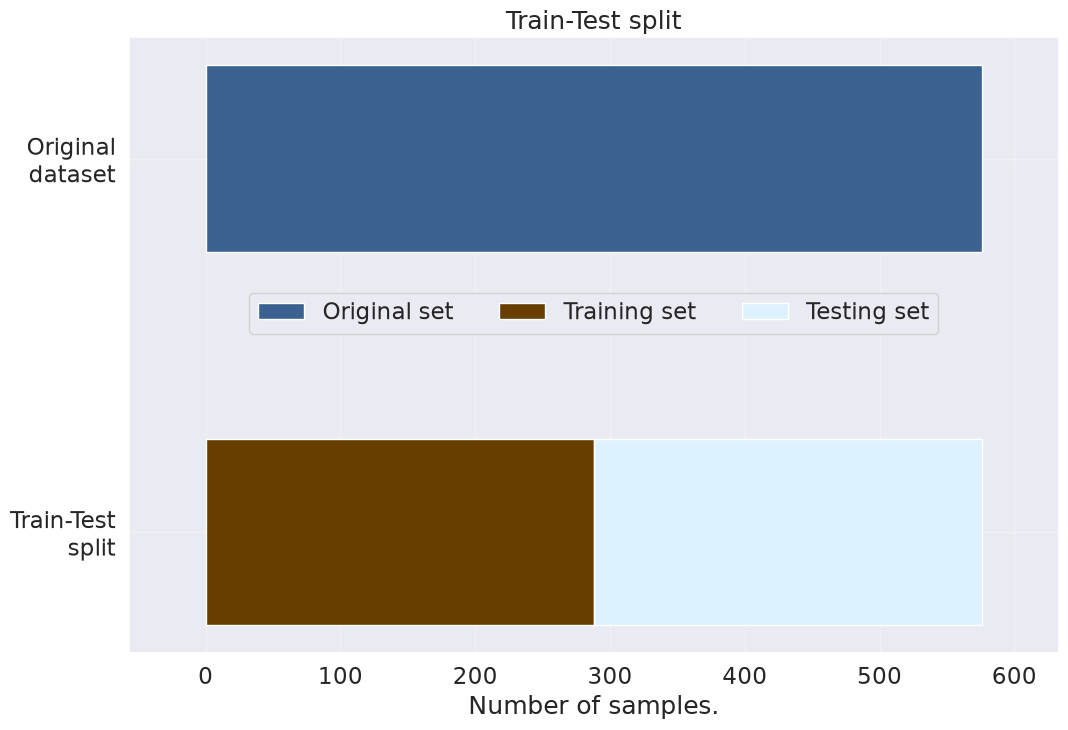

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set(font_scale=1.5)


def plot_simple_train_test(ax, all_dataset, train_set, test_set):
    """Create a sample plot for training-testing split."""
    bd_cmap = ["#3A6190", "#683E00", "#DDF2FF", "#2196F3"]

    ax.barh("Original\ndataset", len(all_dataset), left=0, height=0.5, color=bd_cmap[0])
    ax.barh("Train-Test\nsplit", len(train_set), left=0, height=0.5, color=bd_cmap[1])
    ax.barh(
        "Train-Test\nsplit",
        len(test_set),
        left=len(train_set),
        height=0.5,
        color=bd_cmap[2],
    )

    ax.invert_yaxis()
    ax.set(xlabel="Number of samples.", title="Train-Test split")
    ax.legend(
        ["Original set", "Training set", "Testing set"],
        loc="lower center",
        ncols=4,
        bbox_to_anchor=(0.5, 0.5),
    )
    ax.set_xlim([-int(0.1 * len(all_dataset)), int(1.1 * len(all_dataset))])
    return ax


fig, ax = plt.subplots(figsize=(12, 8))
plot_simple_train_test(
    ax=ax, all_dataset=windows_dataset, train_set=train_set, test_set=test_set
)

In [12]:
from sklearn.model_selection import train_test_split
from skorch.helper import SliceDataset, predefined_split
from torch.utils.data import Subset

X_train = SliceDataset(train_set, idx=0)
y_train = np.array([y for y in SliceDataset(train_set, idx=1)])
train_indices, val_indices = train_test_split(
    X_train.indices_, test_size=0.2, shuffle=False
)
train_subset = Subset(train_set, train_indices)
val_subset = Subset(train_set, val_indices)

In [13]:
clf = EEGClassifier(
    model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    train_split=predefined_split(val_subset),
    optimizer__lr=lr,
    optimizer__weight_decay=weight_decay,
    batch_size=batch_size,
    callbacks=[
        "accuracy",
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
    ],
    device=device,
    classes=classes,
    max_epochs=n_epochs,
)
clf.fit(train_subset, y=None)

# evaluate the model after training and validation
y_test = test_set.get_metadata().target
test_acc = clf.score(test_set, y=y_test)
print(f"Test acc: {(test_acc * 100):.2f}%")

  epoch    train_accuracy    train_loss    valid_acc    valid_accuracy    valid_loss      lr     dur
-------  ----------------  ------------  -----------  ----------------  ------------  ------  ------
      1            0.3261        1.1762       0.2931            0.2931        4.9092  0.0006  0.3659
      2            0.3391        1.1504       0.3276            0.3276        4.2917  0.0000  0.4045
Test acc: 26.39%


<Axes: title={'center': 'Train-Test-Valid split'}, xlabel='Number of samples.'>

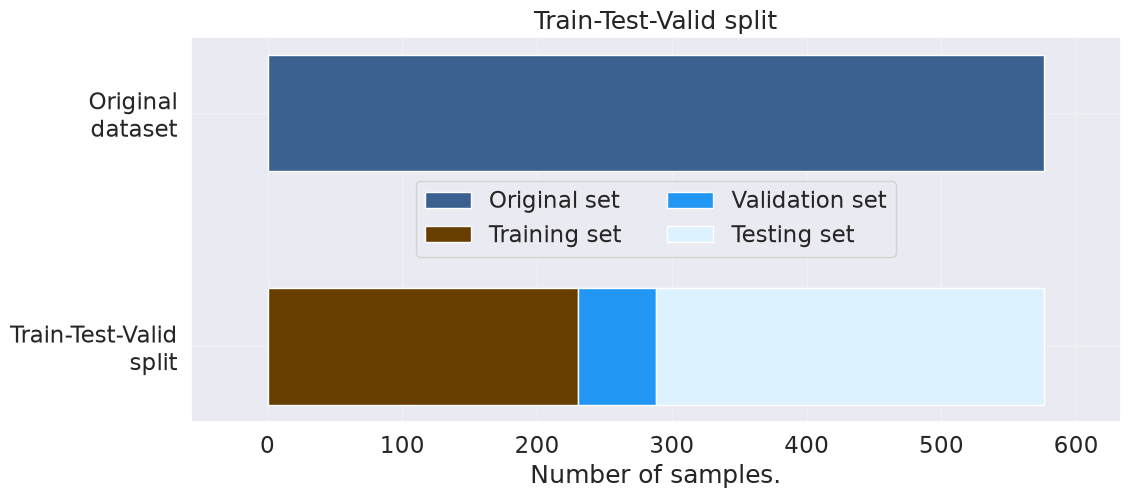

In [14]:
def plot_train_valid_test(ax, all_dataset, train_subset, val_subset, test_set):
    """Create a sample plot for training, validation, testing."""
    bd_cmap = [
        "#3A6190",
        "#683E00",
        "#2196F3",
        "#DDF2FF",
    ]

    n_train, n_val, n_test = len(train_subset), len(val_subset), len(test_set)
    ax.barh("Original\ndataset", len(all_dataset), left=0, height=0.5, color=bd_cmap[0])
    ax.barh("Train-Test-Valid\nsplit", n_train, left=0, height=0.5, color=bd_cmap[1])
    ax.barh(
        "Train-Test-Valid\nsplit", n_val, left=n_train, height=0.5, color=bd_cmap[2]
    )
    ax.barh(
        "Train-Test-Valid\nsplit",
        n_test,
        left=n_train + n_val,
        height=0.5,
        color=bd_cmap[3],
    )

    ax.invert_yaxis()
    ax.set(xlabel="Number of samples.", title="Train-Test-Valid split")
    ax.legend(
        ["Original set", "Training set", "Validation set", "Testing set"],
        loc="lower center",
        ncols=2,
        bbox_to_anchor=(0.5, 0.4),
    )
    ax.set_xlim([-int(0.1 * len(all_dataset)), int(1.1 * len(all_dataset))])
    return ax


fig, ax = plt.subplots(figsize=(12, 5))
plot_train_valid_test(
    ax=ax,
    all_dataset=windows_dataset,
    train_subset=train_subset,
    val_subset=val_subset,
    test_set=test_set,
)



In [15]:
from sklearn.model_selection import KFold, cross_val_score
from skorch.callbacks import LRScheduler

from braindecode import EEGClassifier

lr = 0.0625 * 0.01
weight_decay = 0
batch_size = 64
n_epochs = 2

clf = EEGClassifier(
    model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    train_split=None,
    optimizer__lr=lr,
    optimizer__weight_decay=weight_decay,
    batch_size=batch_size,
    callbacks=[
        "accuracy",
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
    ],
    device=device,
    classes=classes,
    max_epochs=n_epochs,
)

train_val_split = KFold(n_splits=5, shuffle=False)
# By setting n_jobs=-1, cross-validation is performed
# with all the processors, in this case the output of the training
# process is not printed sequentially
cv_results = cross_val_score(
    clf, X_train, y_train, scoring="accuracy", cv=train_val_split, n_jobs=1
)
print(
    f"Validation accuracy: {np.mean(cv_results * 100):.2f}"
    f"+-{np.std(cv_results * 100):.2f}%"
)

  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.2652        1.1800  0.0006  0.3976
      2            0.2739        1.0704  0.0000  0.3442
  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.2739        1.1930  0.0006  0.3260
      2            0.2957        1.0587  0.0000  0.3299
  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.3609        1.2132  0.0006  0.3497
      2            0.3565        1.0497  0.0000  0.3284
  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.2900        1.1381  0.0006  0.3188
      2            0.2987        1.0374  0.0000  0.3592
  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------ 

<Axes: title={'center': 'KFold Train-Test-Valid split'}, xlabel='Number of samples.'>

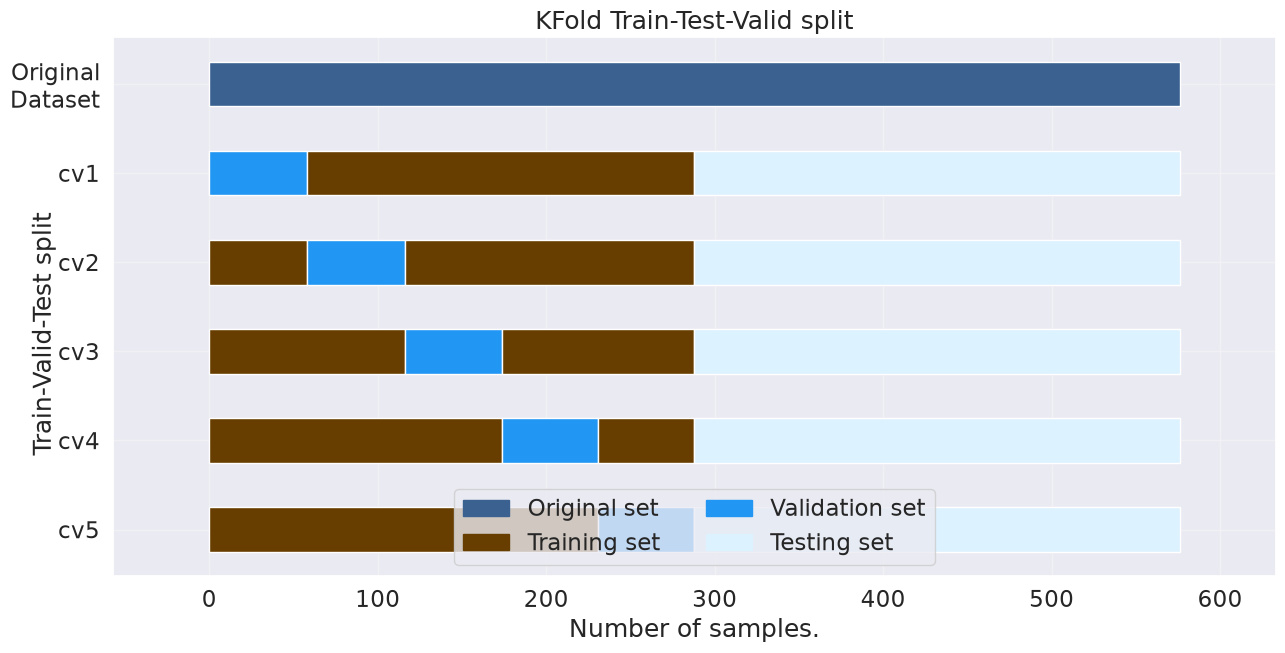

In [16]:
def plot_k_fold(ax, cv, all_dataset, X_train, y_train, test_set):
    """Create a sample plot for training, validation, testing."""
    bd_cmap = [
        "#3A6190",
        "#683E00",
        "#2196F3",
        "#DDF2FF",
    ]

    ax.barh("Original\nDataset", len(all_dataset), left=0, height=0.5, color=bd_cmap[0])

    # Generate the training/validation/testing data fraction visualizations for each CV split
    for ii, (tr_idx, val_idx) in enumerate(cv.split(X=X_train, y=y_train)):
        n_train, n_val, n_test = len(tr_idx), len(val_idx), len(test_set)
        n_train2 = n_train + n_val - max(val_idx) - 1
        ax.barh("cv" + str(ii + 1), min(val_idx), left=0, height=0.5, color=bd_cmap[1])
        ax.barh(
            "cv" + str(ii + 1), n_val, left=min(val_idx), height=0.5, color=bd_cmap[2]
        )
        ax.barh(
            "cv" + str(ii + 1),
            n_train2,
            left=max(val_idx) + 1,
            height=0.5,
            color=bd_cmap[1],
        )
        ax.barh(
            "cv" + str(ii + 1),
            n_test,
            left=n_train + n_val,
            height=0.5,
            color=bd_cmap[3],
        )

    ax.invert_yaxis()
    ax.set_xlim([-int(0.1 * len(all_dataset)), int(1.1 * len(all_dataset))])
    ax.set(xlabel="Number of samples.", title="KFold Train-Test-Valid split")
    ax.legend(
        [Patch(color=bd_cmap[i]) for i in range(4)],
        ["Original set", "Training set", "Validation set", "Testing set"],
        loc="lower center",
        ncols=2,
    )
    ax.text(
        -0.07,
        0.45,
        "Train-Valid-Test split",
        rotation=90,
        verticalalignment="center",
        horizontalalignment="left",
        transform=ax.transAxes,
    )
    return ax


fig, ax = plt.subplots(figsize=(15, 7))
plot_k_fold(
    ax,
    cv=train_val_split,
    all_dataset=windows_dataset,
    X_train=X_train,
    y_train=y_train,
    test_set=test_set,
)

In [17]:
import pandas as pd
from sklearn.model_selection import GridSearchCV

train_val_split = [
    tuple(train_test_split(X_train.indices_, test_size=0.2, shuffle=False))
]

param_grid = {
    "optimizer__lr": [0.00625, 0.000625],
}

# By setting n_jobs=-1, grid search is performed
# with all the processors, in this case the output of the training
# process is not printed sequentially
search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=train_val_split,
    return_train_score=True,
    scoring="accuracy",
    refit=True,
    verbose=1,
    error_score="raise",
    n_jobs=1,
)

search.fit(X_train, y_train)
search_results = pd.DataFrame(search.cv_results_)

best_run = search_results[search_results["rank_test_score"] == 1].squeeze()

best_parameters = best_run["params"]


Fitting 1 folds for each of 2 candidates, totalling 2 fits
  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.3304        1.3693  0.0063  0.3547
      2            0.3957        1.3278  0.0000  0.3589
  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.2783        1.2240  0.0006  0.3320
      2            0.2913        1.0090  0.0000  0.3369
  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.2639        1.1834  0.0006  0.4584
      2            0.2743        1.0415  0.0000  0.5201


In [18]:
train_val_split = KFold(n_splits=5, shuffle=False)